In [1]:
import sys
sys.path.append('..')  # Add parent directory to path

from denoising import DenoisingPipeline
from denoising.config import load_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [ ]:
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
import nibabel as nib
import numpy as np

In [2]:
from pathlib import Path
datapath = Path(r'C:\Users\administrator\Desktop\data\stress_data\bids_control\derivatives\sub-01')

In [14]:
img = nib.load(r"C:\Users\administrator\Desktop\data\stress_data\bids_control\derivatives\sub-01\func\sub-01_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz")

In [16]:
conf = pd.read_csv(
    r"C:\Users\administrator\Desktop\data\stress_data\bids_control\derivatives\sub-01\func\sub-01_task-rest_desc-confounds_timeseries.tsv", sep='\t')

In [22]:
img.shape

(93, 116, 60, 400)

In [20]:
conf

,global_signal,global_signal_derivative1,global_signal_power2,global_signal_derivative1_power2,csf,csf_derivative1,csf_derivative1_power2,csf_power2,white_matter,white_matter_derivative1,...,rot_z_derivative1_power2,rot_z_power2,motion_outlier00,motion_outlier01,motion_outlier02,motion_outlier03,motion_outlier04,motion_outlier05,motion_outlier06,motion_outlier07
0,2786.627255,NaN,7.765291e+06,NaN,3321.092212,NaN,NaN,1.102965e+07,2577.214019,NaN,...,NaN,4.225000e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2317.508791,-469.118464,5.370847e+06,220072.133471,2890.938486,-430.153726,185032.228326,8.357525e+06,2120.487649,-456.726371,...,4.225005e-09,1.430637e-21,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2173.539521,-143.969269,4.724274e+06,20727.150486,2696.724477,-194.214009,37719.081257,7.272323e+06,2020.821110,-99.666539,...,1.207845e-21,9.423092e-24,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2126.612981,-46.926541,4.522483e+06,2202.100225,2595.392506,-101.331970,10268.168194,6.736062e+06,1998.216355,-22.604756,...,3.713985e-16,3.712801e-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2108.602687,-18.010294,4.446205e+06,324.370676,2540.948171,-54.444336,2964.185690,6.456418e+06,1989.939538,-8.276817,...,3.710025e-16,5.192340e-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,2085.518292,-1.238294,4.349387e+06,1.533372,2477.318611,-2.161760,4.673208,6.137108e+06,1978.811773,1.073080,...,6.551535e-08,3.249615e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
396,2085.440158,-0.078134,4.349061e+06,0.006105,2471.151303,-6.167308,38.035690,6.106589e+06,1978.052220,-0.759553,...,2.488145e-08,5.296820e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
397,2080.106669,-5.333489,4.326844e+06,28.446103,2460.969769,-10.181534,103.663628,6.056372e+06,1978.356182,0.303962,...,1.617675e-11,5.238437e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
398,2077.497913,-2.608756,4.315998e+06,6.805609,2454.268755,-6.701015,44.903595,6.023435e+06,1975.252893,-3.103289,...,1.000840e-08,3.890372e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
sum(conf.global_signal < conf.global_signal.mean())

248

In [24]:
gs = conf.global_signal.values
mask = nib.load(r"C:\Users\administrator\Desktop\data\stress_data\bids_control\derivatives\sub-01\func\sub-01_task-rest_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz")

In [ ]:

# read func and mask files 
#func_files = data.get_func_files(sub)[0]
#mask_files = data.get_mask_files(sub)[0]
# get global signal from confounds file
#gs = data.get_confounds_one_subject(sub)[0].global_signal.values

mskr = NiftiMasker(mask_img=mask, standardize=False)
mskr.fit(img)
tr = mskr.transform(img)

# смотрим сигнал вокселя в определенный момент времени
# если он больше глобального сигнала, то оставляем
a = np.array([tr[i] > (gs[i] * 0.6) for i in range(len(gs))])
t = tr * a

out_mask = mskr.inverse_transform(np.sum(t, axis=0) != 0)
#nib.save(out_mask, 'sub-1_run-2_new_mask.nii.gz')
    

C:\Users\administrator\AppData\Local\Temp\ipykernel_20668\2556409181.py:8: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  mskr.fit(img)


In [32]:
a

array([[False, False, False, ..., False, False,  True],
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False,  True,  True],
       ...,
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False,  True,  True]],
      shape=(400, 274428))

In [30]:
tr.shape

(400, 274428)

In [31]:
out_mask

In [27]:
new_mask_gsr(img, mask, gs, r'C:\Users\administrator\Desktop\projects\Denoising\notebooks')

C:\Users\administrator\AppData\Local\Temp\ipykernel_20668\3459327363.py:11: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  mskr.fit(func_files)


In [33]:
cache_dir = Path.home() / "nilearn_data" / "brainnetome"

In [34]:
cache_dir

WindowsPath('C:/Users/administrator/nilearn_data/brainnetome')

In [35]:
atlas_img = nib.load(r"C:\Users\administrator\nilearn_data\schaefer_2018\Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
#masker_labels = atlas.atlas_labels


# все что не ноль то один
# создаем бинарный атлас, чтобы потом считтать воксели
atlas_img_bin = nib.Nifti1Image(
    (atlas_img.get_fdata() > 0).astype(np.uint8), 
    atlas_img.affine, 
    atlas_img.header,)


In [36]:
sum_masker_masked = NiftiLabelsMasker(
                        labels_img=atlas_img,
                        #labels=masker_labels,
                        background_label=0,
                        mask_img=mask,
                        smoothing_fwhm=None,
                        standardize=False,
                        strategy="sum",
                        resampling_target='data',  # !!!!!!!!!!!!!!!!!!!! check resampling 
                        )

# no mask image here !!
sum_masker_unmasked = NiftiLabelsMasker(
                        labels_img=atlas_img,
                        #labels=masker_labels,
                        background_label=0,
                        smoothing_fwhm=None,
                        standardize=False,
                        strategy="sum", # sum to see number of 
                        resampling_target='data',
                        )


# вместо мозга передаем бинаризованый атлас, 
# и считаем сколько вокселей попадает в маску (суммируем количество вокселей в рои)
n_voxels_in_masked_parcels = sum_masker_masked.fit_transform(atlas_img_bin)
# считаем сколько всего вокселей в рои в атласе
n_voxels_in_parcels = sum_masker_unmasked.fit_transform(atlas_img_bin)
# процент вокселей в маске
parcel_coverage = np.squeeze(n_voxels_in_masked_parcels / n_voxels_in_parcels)


(array([  1.,   0.,   0.,   2.,   3.,   0.,   3.,   2.,  10., 379.]),
 array([0.41747573, 0.47572816, 0.53398058, 0.59223301, 0.65048544,
        0.70873786, 0.76699029, 0.82524272, 0.88349515, 0.94174757,
        1.        ]),
 <BarContainer object of 10 artists>)

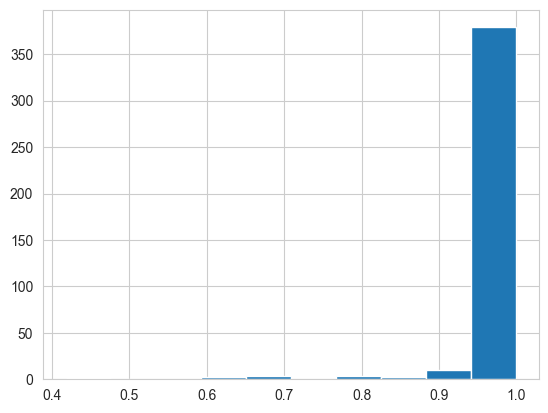

In [40]:
plt.hist(parcel_coverage, bins=10)

In [6]:
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
import nibabel as nib
import numpy as np


def new_mask_gsr(data, path_to_save, thr=0.6):

    for sub in data.sub_labels:
        try:
            # read func and mask files 
            func_files = data.get_func_files(sub)[0]
            mask_files = data.get_mask_files(sub)[0]
            # get global signal from confounds file
            gs = data.get_confounds_one_subject(sub)[0].global_signal.values

            mskr = NiftiMasker(mask_img=mask_files)
            mskr.fit(func_files)
            tr = mskr.transform(func_files)
            
            # смотрим сигнал вокселя в определенный момент времени
            # если он больше глобального сигнала, то оставляем
            a = np.array([tr[i] > (gs[i] * thr) for i in range(120)])
            t = tr * a

            out_mask = mskr.inverse_transform(np.sum(t, axis=0) != 0)
            nib.save(out_mask, f'{path_to_save}/sub-{sub}_run-1_new_mask.nii.gz')
        
        except IndexError:
            print(sub)
            continue

def coverage(atlas, mask):
    atlas_img = nib.load(atlas.atlas_path)
    masker_labels = atlas.atlas_labels
    

    # все что не ноль то один
    # создаем бинарный атлас, чтобы потом считтать воксели
    atlas_img_bin = nib.Nifti1Image(
        (atlas_img.get_fdata() > 0).astype(np.uint8), 
        atlas_img.affine, 
        atlas_img.header,)


    sum_masker_masked = NiftiLabelsMasker(
                            labels_img=atlas_img,
                            labels=masker_labels,
                            background_label=0,
                            mask_img=mask,
                            smoothing_fwhm=None,
                            standardize=False,
                            strategy="sum",
                            resampling_target='data',  # !!!!!!!!!!!!!!!!!!!! check resampling 
                            )

    # no mask image here !!
    sum_masker_unmasked = NiftiLabelsMasker(
                            labels_img=atlas_img,
                            labels=masker_labels,
                            background_label=0,
                            smoothing_fwhm=None,
                            standardize=False,
                            strategy="sum", # sum to see number of 
                            resampling_target='data',
                            )


    # вместо мозга передаем бинаризованый атлас, 
    # и считаем сколько вокселей попадает в маску (суммируем количество вокселей в рои)
    n_voxels_in_masked_parcels = sum_masker_masked.fit_transform(atlas_img_bin)
    # считаем сколько всего вокселей в рои в атласе
    n_voxels_in_parcels = sum_masker_unmasked.fit_transform(atlas_img_bin)
    # процент вокселей в маске
    parcel_coverage = np.squeeze(n_voxels_in_masked_parcels / n_voxels_in_parcels)


    